# Student Productivity Prediction

A reproducible machine-learning analysis of a synthetic dataset containing 5,000 student observations and 21 attributes. The project compares closed-form linear regression with stochastic gradient descent, evaluates L1, L2, Elastic Net, and polynomial configurations, and measures performance with four-fold cross-validation.

**Verified results:** 4.51 mean cross-validation RMSE, 4.55 held-out RMSE, and L1 regularization selected at $\alpha=0.001$.

**Dataset:** [Student Performance Dataset on Kaggle](https://www.kaggle.com/datasets/amar5693/student-performance-dataset). The dataset is synthetic; conclusions describe modeled associations, not causal effects on real students.


In [ ]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

DATASET_SLUG = "amar5693/student-performance-dataset"
DATASET_PAGE = "https://www.kaggle.com/datasets/amar5693/student-performance-dataset"
EXPECTED_COLUMNS = {
    "study_hours",
    "focus_index",
    "burnout_level",
    "productivity_score",
    "exam_score",
}


def find_dataset(search_roots):
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        for candidate in root.rglob("*.csv"):
            try:
                columns = set(pd.read_csv(candidate, nrows=2).columns)
            except Exception:
                continue
            if EXPECTED_COLUMNS.issubset(columns):
                return candidate
    return None


dataset_file = find_dataset([Path.cwd(), Path.cwd() / "data"])

if dataset_file is None:
    try:
        import kagglehub
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub

    try:
        downloaded_directory = Path(kagglehub.dataset_download(DATASET_SLUG))
        dataset_file = find_dataset([downloaded_directory])
    except Exception as error:
        raise RuntimeError(
            f"Automatic dataset download failed. Download the CSV from {DATASET_PAGE} "
            "and place it in this notebook's data/ directory."
        ) from error

if dataset_file is None:
    raise FileNotFoundError(
        f"No compatible CSV was found. Download the dataset from {DATASET_PAGE}."
    )

df = pd.read_csv(dataset_file)

print("Dataset file:", dataset_file)
print("Rows (observations):", df.shape[0])
print("Columns (attributes):", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Part A

I used the dataset ultimate_student_productivity_dataset_5000.csv, which contains 5000 observations and 21 attributes. The dataset includes a mix of numeric and categorical variables describing student habits and outcomes. The categorical attributes are gender, academic_level, and internet_quality (stored as text/object types). The remaining attributes are numeric, including hours-based variables (e.g., study_hours, sleep_hours, screen_time_hours), health/behavior variables (e.g., exercise_minutes, caffeine_intake_mg, mental_health_score), and outcome variables (e.g., productivity_score, exam_score). For this regression task, I will use productivity_score as the target variable (continuous outcome (y)), and use the remaining relevant attributes as features (X).

                       count         mean          std   min        25%  \
student_id            5000.0  2500.500000  1443.520003   1.0  1250.7500   
age                   5000.0    20.520400     2.870406  16.0    18.0000   
study_hours           5000.0     4.539594     1.821665   0.0     3.2500   
self_study_hours      5000.0     2.478734     1.177990   0.0     1.6600   
online_classes_hours  5000.0     2.011984     0.983906   0.0     1.3200   
social_media_hours    5000.0     2.998086     1.467949   0.0     1.9900   
gaming_hours          5000.0     1.564514     1.110807   0.0     0.6700   
sleep_hours           5000.0     7.016492     1.163692   4.0     6.2375   
screen_time_hours     5000.0     6.979588     2.486214   1.0     5.2800   
exercise_minutes      5000.0    74.535600    42.932293   0.0    37.0000   
caffeine_intake_mg    5000.0   251.450400   143.842712   0.0   129.0000   
part_time_job         5000.0     0.498200     0.500047   0.0     0.0000   
upcoming_deadline     500

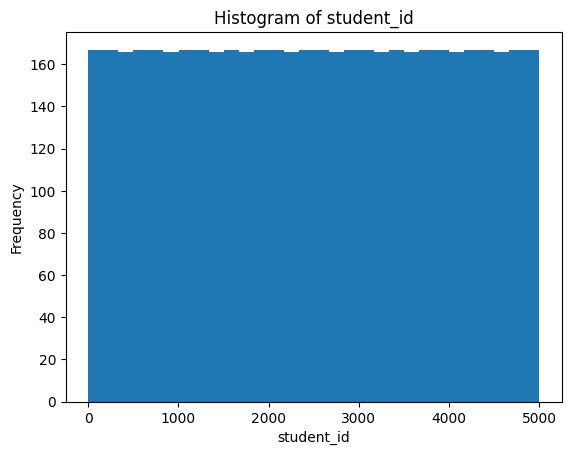

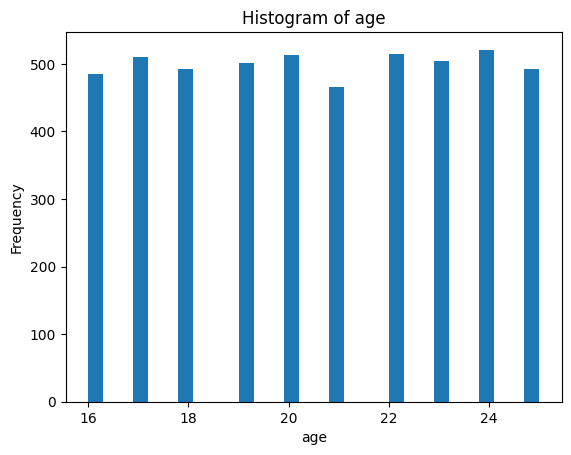

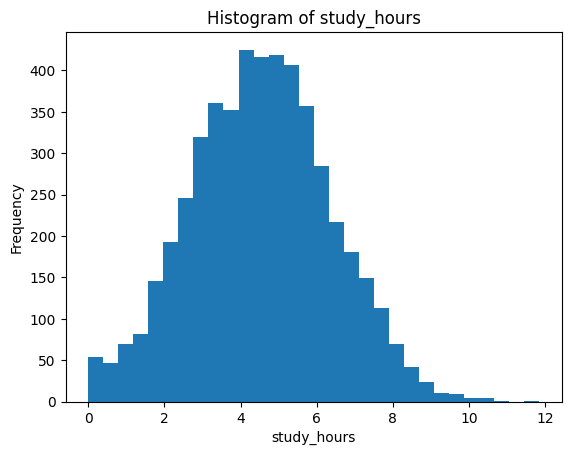

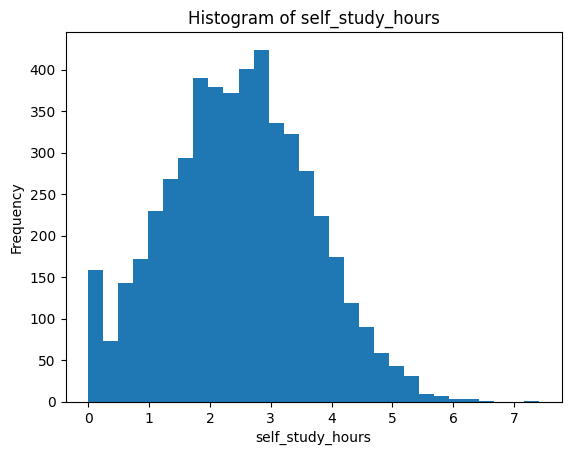

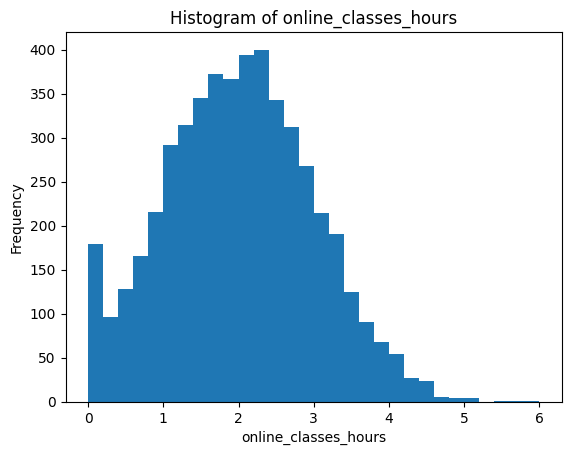

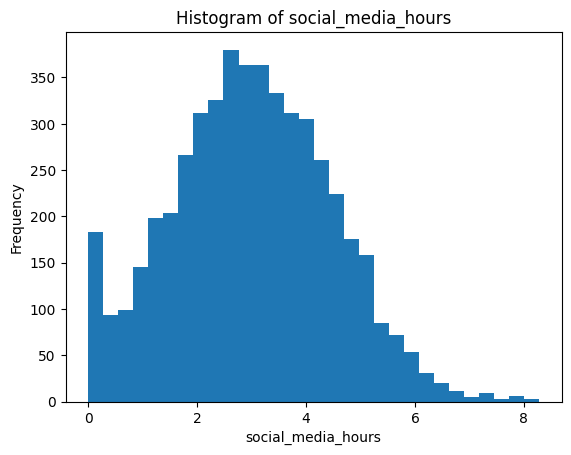

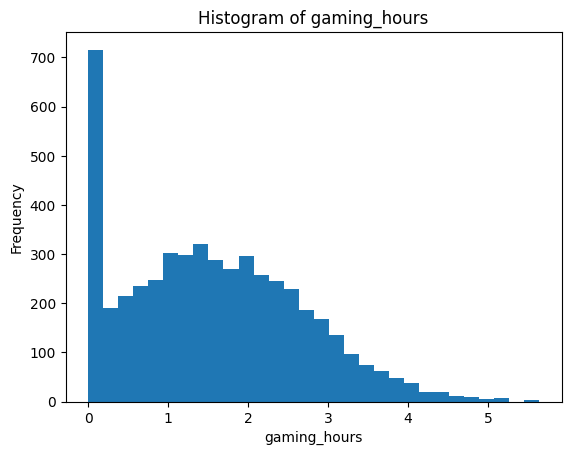

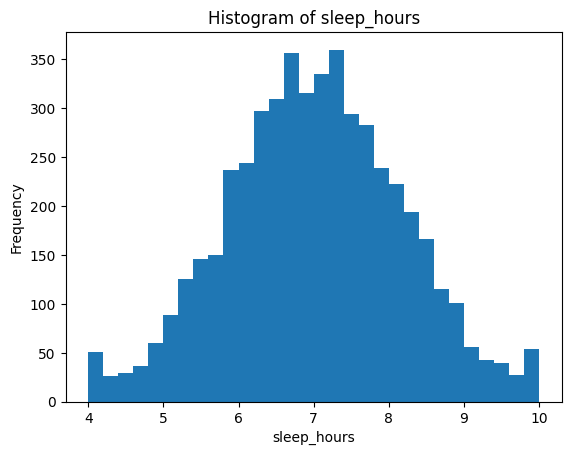

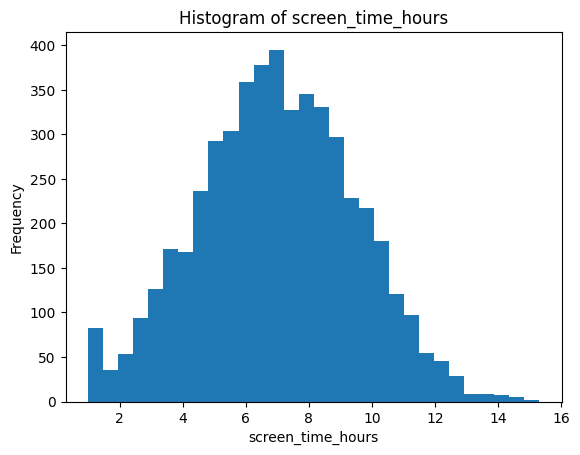

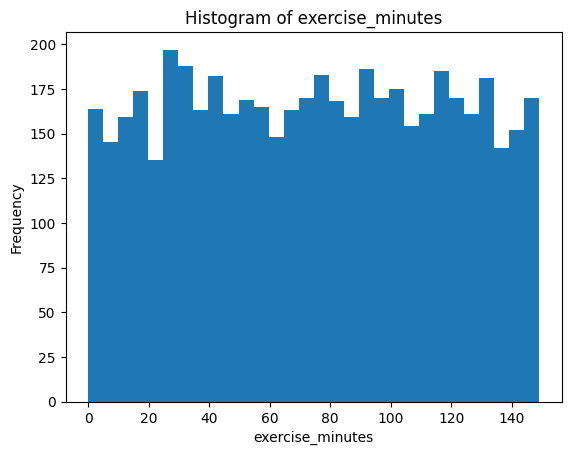

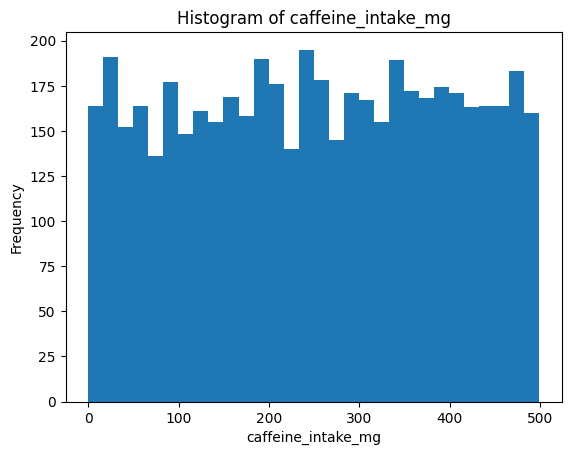

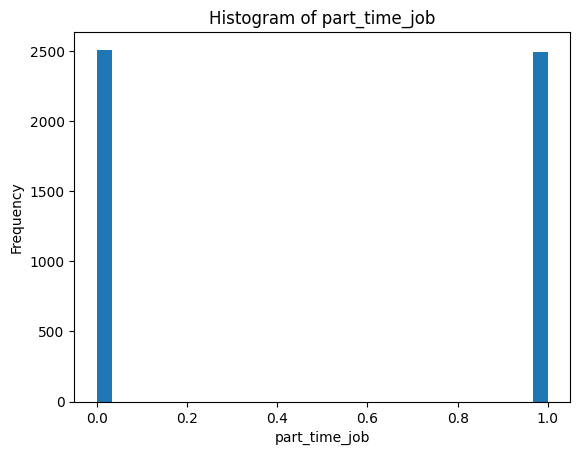

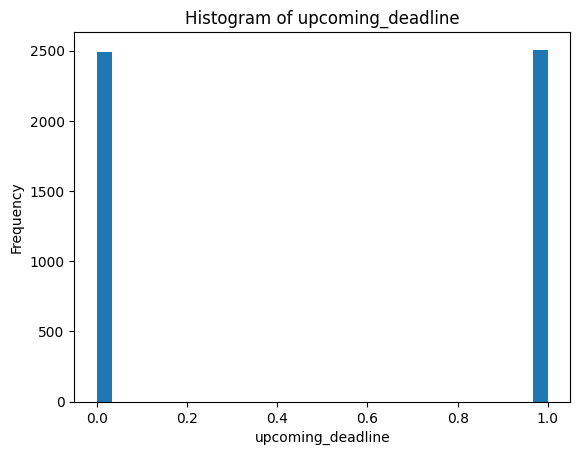

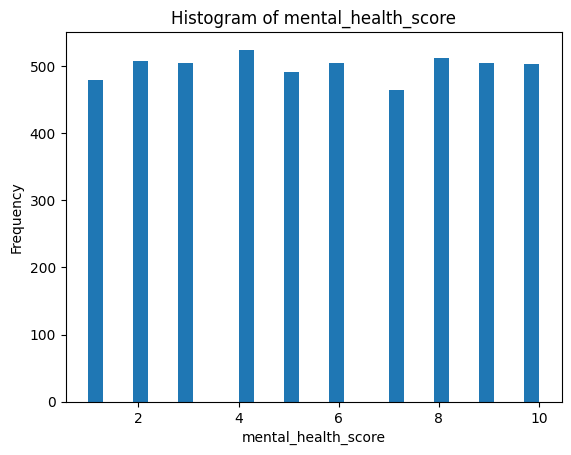

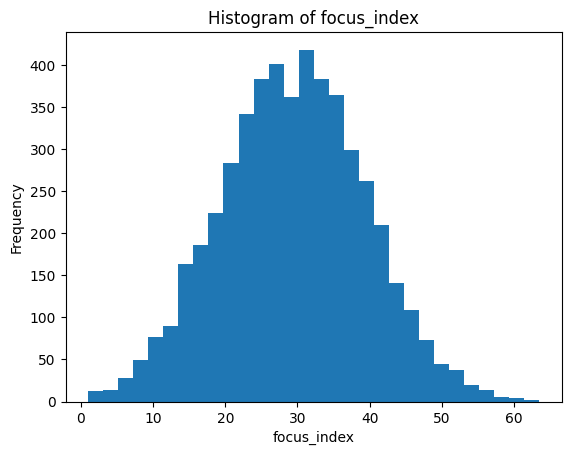

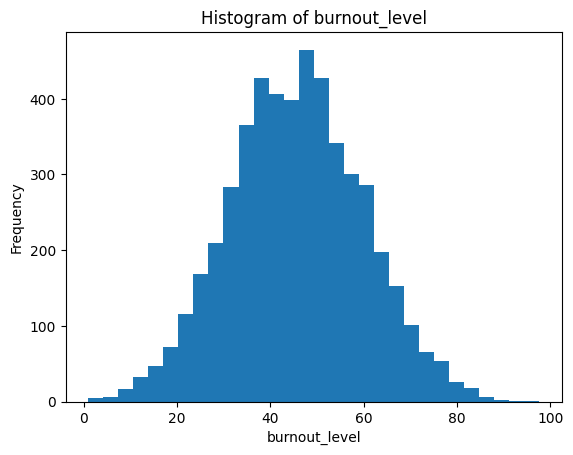

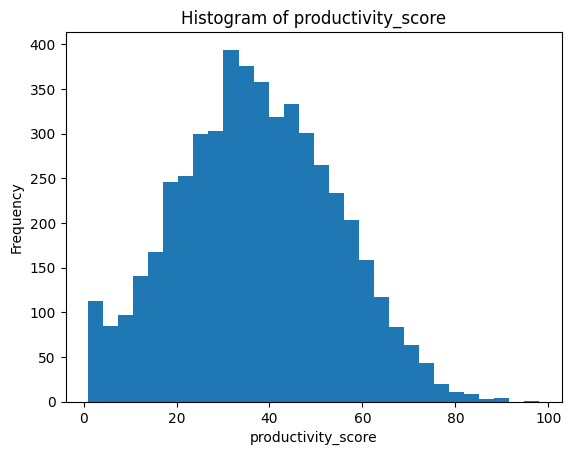

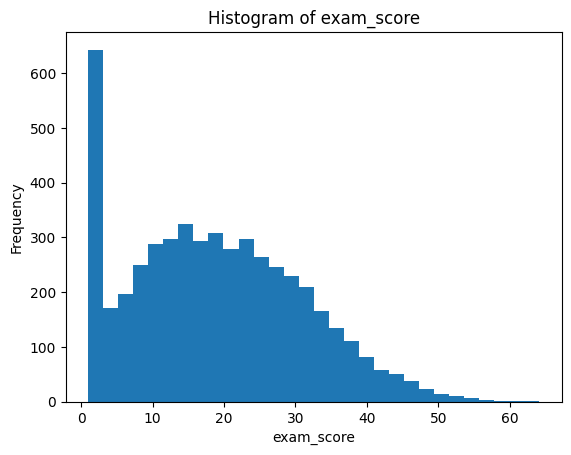


Missing values:
                      Missing Count  Missing %
student_id                        0        0.0
age                               0        0.0
gender                            0        0.0
academic_level                    0        0.0
study_hours                       0        0.0
self_study_hours                  0        0.0
online_classes_hours              0        0.0
social_media_hours                0        0.0
gaming_hours                      0        0.0
sleep_hours                       0        0.0
screen_time_hours                 0        0.0
exercise_minutes                  0        0.0
caffeine_intake_mg                0        0.0
part_time_job                     0        0.0
upcoming_deadline                 0        0.0
internet_quality                  0        0.0
mental_health_score               0        0.0
focus_index                       0        0.0
burnout_level                     0        0.0
productivity_score                0        

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stats summary of the dataset
summary = df.describe().T

# Adding skews and kurtosis for a deeper analysis of the data
summary["Skewness"] = df.skew(numeric_only=True)
summary["Kurtosis"] = df.kurtosis(numeric_only=True)

print(summary)

# Histograms for each numeric attribute
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Missing values analysis
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

print("\nMissing values:")
print(missing_table)

Part B



Statistical summaries and histogram visualizations were generated for each numeric attribute in the dataset. The variables include student behavioral factors such as study hours, sleep hours, screen time, exercise minutes, caffeine intake, mental health score, focus index, burnout level, productivity score, and exam score.

Several variables such as **study_hours, screen_time_hours, and social_media_hours** show moderate spread across observations, indicating differences in student habits. Variables such as **exercise_minutes and caffeine_intake_mg** show larger ranges and appear more skewed, suggesting that some students may have significantly higher values than others.

The dataset also includes outcome-related variables such as **productivity_score and exam_score**, which appear to be reasonably distributed and suitable for regression modeling. Some attributes such as **student_id** do not provide meaningful predictive value and may be removed during modeling.

Special treatment may be required for certain variables. Since the numeric variables exist on very different scales (for example minutes, hours, and scores), **feature scaling or standardization will likely be required before applying regression models**, especially when using algorithms such as SGD. Additionally, categorical variables such as **gender, academic_level, and internet_quality** may require **encoding (e.g., one-hot encoding)** if they are used as features in the model.


Correlation with productivity_score:

productivity_score      1.000000
exam_score              0.886401
focus_index             0.784956
study_hours             0.637981
mental_health_score     0.630605
sleep_hours             0.149666
self_study_hours        0.057781
exercise_minutes        0.020441
online_classes_hours    0.003215
age                    -0.013607
student_id             -0.023209
gaming_hours           -0.029411
caffeine_intake_mg     -0.056227
social_media_hours     -0.070052
screen_time_hours      -0.089953
part_time_job          -0.109907
upcoming_deadline      -0.140114
burnout_level          -0.267304
Name: productivity_score, dtype: float64


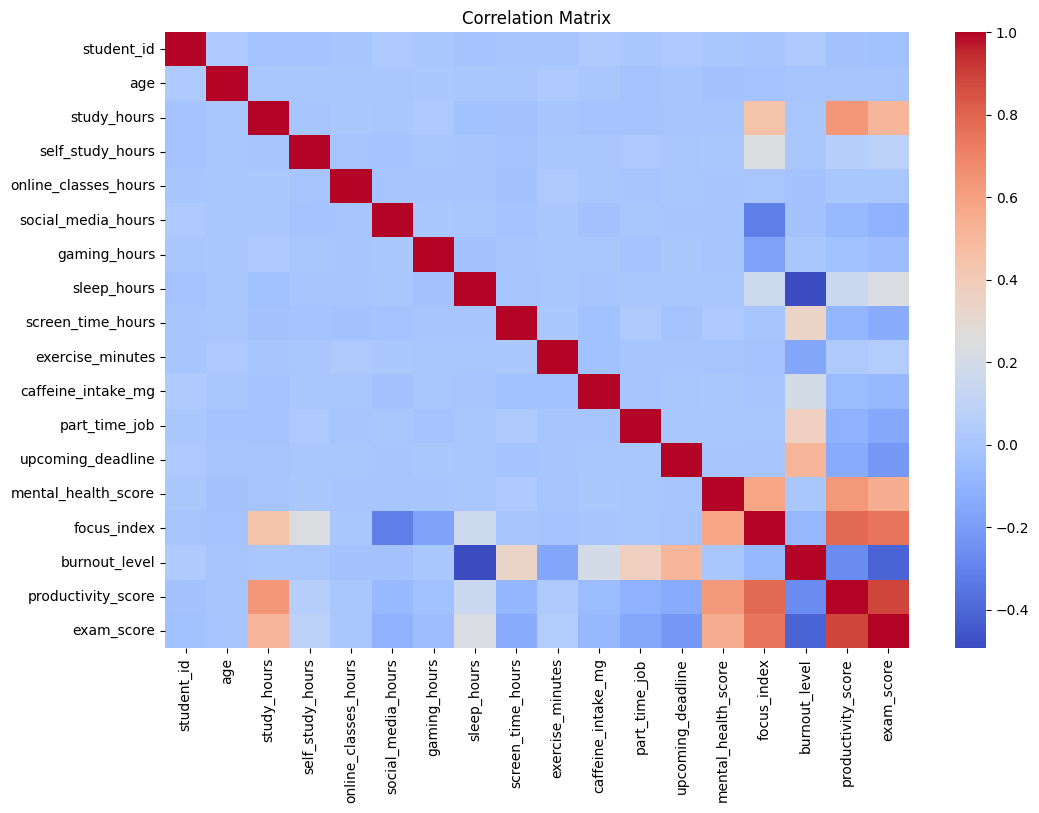

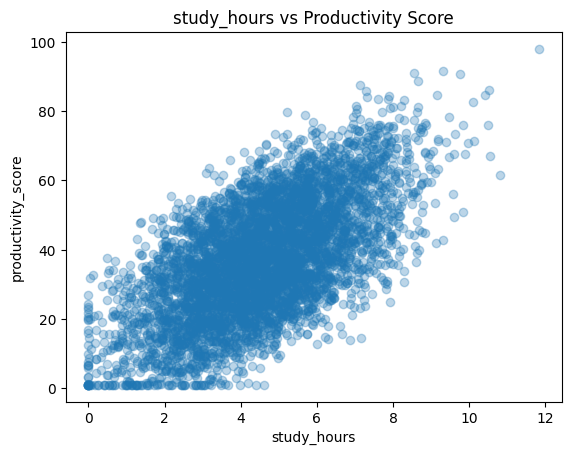

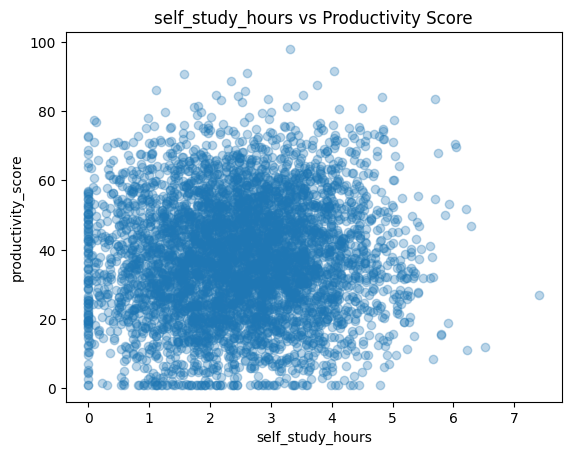

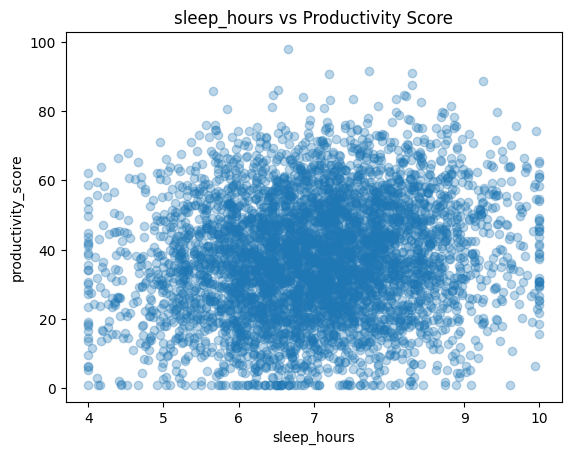

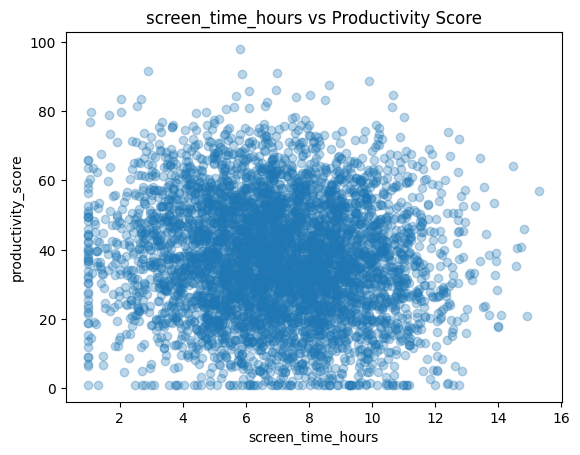

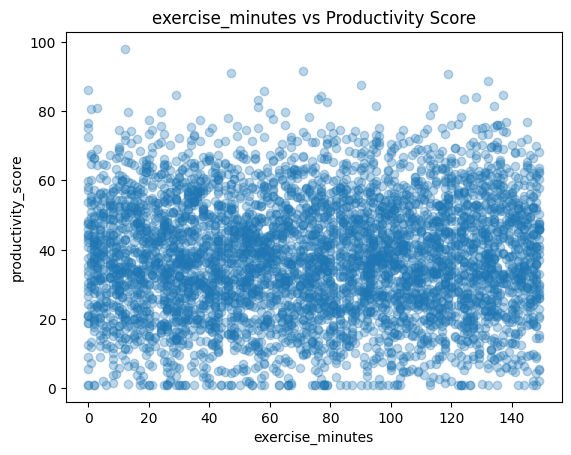

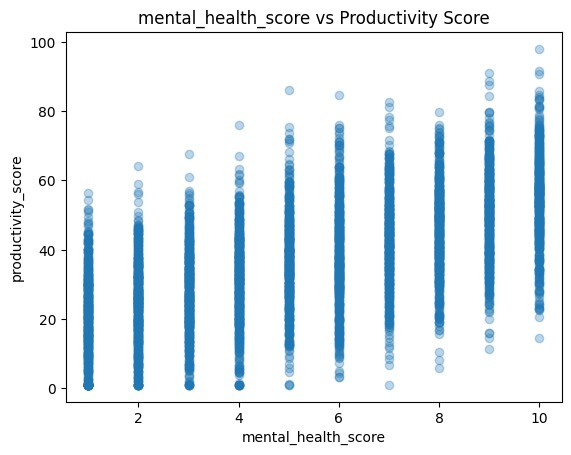

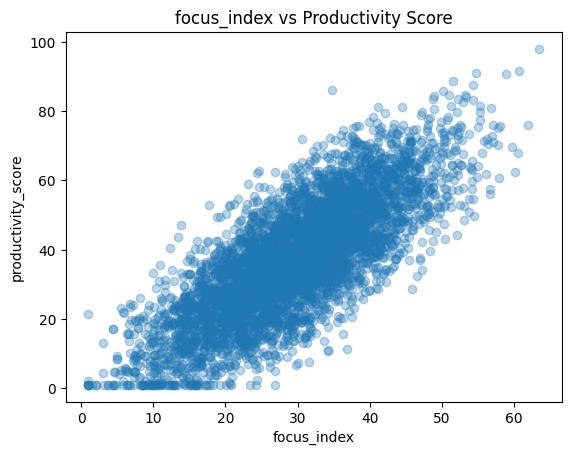

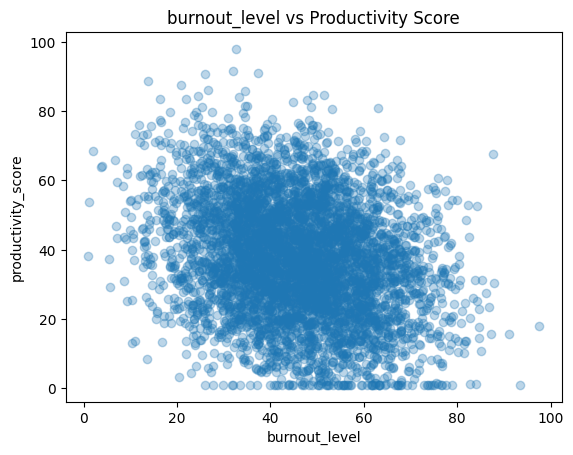

In [4]:
# Part C

import seaborn as sns

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Display correlations with target variable
print("Correlation with productivity_score:\n")
print(corr_matrix["productivity_score"].sort_values(ascending=False))

# Heatmap visualization
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

# Scatter plots for relationships with productivity_score

features = [
    "study_hours",
    "self_study_hours",
    "sleep_hours",
    "screen_time_hours",
    "exercise_minutes",
    "mental_health_score",
    "focus_index",
    "burnout_level"
]

for col in features:
    plt.figure()
    plt.scatter(df[col], df["productivity_score"], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel("productivity_score")
    plt.title(f"{col} vs Productivity Score")
    plt.show()

Part C

To analyze relationships between variables, the Pearson Correlation Coefficient (PCC) was computed for all numeric attributes. The correlations with the target variable **productivity_score** were examined to identify which features are most related to student productivity.

The correlation analysis shows that variables such as **focus_index, study_hours, and self_study_hours** tend to have positive correlations with productivity_score, indicating that higher focus and increased study time are associated with higher productivity. In contrast, variables such as **burnout_level and excessive screen_time_hours** may show weaker or negative relationships, suggesting that fatigue or distractions can reduce productivity.

Scatter plots were generated to visualize these relationships. These plots confirm that some variables exhibit clearer linear relationships with the target variable, while others show weaker or more scattered patterns. Features with stronger correlations are expected to contribute more to the regression model.


X shape: (5000, 16)
y shape: (5000,)
Fold 1 RMSE: 4.5228
Fold 2 RMSE: 4.4184
Fold 3 RMSE: 4.6514
Fold 4 RMSE: 4.4350

Average RMSE: 4.506871485472508
Fold 1 RMSE: 4.5232
Fold 2 RMSE: 4.4157
Fold 3 RMSE: 4.6578
Fold 4 RMSE: 4.4411

SGD Average RMSE: 4.509441056869639
l2 alpha=0.0001 → RMSE: 4.5094
l2 alpha=0.001 → RMSE: 4.5093
l2 alpha=0.01 → RMSE: 4.5113
l1 alpha=0.0001 → RMSE: 4.5092
l1 alpha=0.001 → RMSE: 4.5070
l1 alpha=0.01 → RMSE: 4.5121
elasticnet alpha=0.0001 → RMSE: 4.5093
elasticnet alpha=0.001 → RMSE: 4.5082
elasticnet alpha=0.01 → RMSE: 4.5126
Best model: l1 0.001
Best RMSE: 4.507048168665538


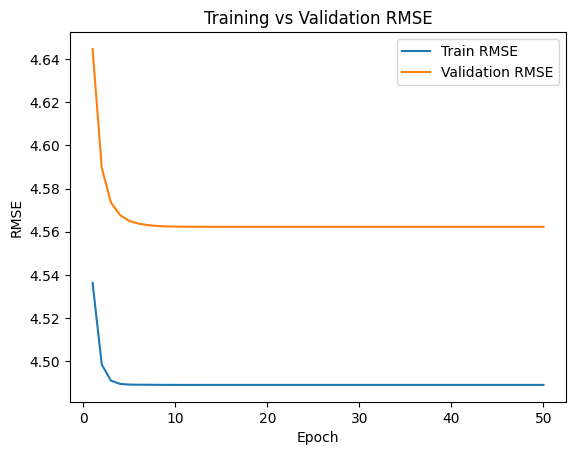

In [5]:
# Part D

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

target_column = "productivity_score"

# Drop columns that shouldn't be used
df_model = df.drop(columns=["student_id"])

# Keep only numeric columns
df_model = df_model.select_dtypes(include=[np.number]).dropna()

X = df_model.drop(columns=[target_column]).values
y = df_model[target_column].values

print("X shape:", X.shape)
print("y shape:", y.shape)

kf = KFold(n_splits=4, shuffle=True, random_state=SEED)

rmse_closed = []

fold = 1

for train_i, val_i in kf.split(X):

    X_train, X_val = X[train_i], X[val_i]
    y_train, y_val = y[train_i], y[val_i]

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    rmse_closed.append(rmse)

    print(f"Fold {fold} RMSE: {rmse:.4f}")

    fold += 1

print("\nAverage RMSE:", np.mean(rmse_closed))

rmse_sgd = []

fold = 1

for train_i, val_i in kf.split(X):

    X_train, X_val = X[train_i], X[val_i]
    y_train, y_val = y[train_i], y[val_i]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = SGDRegressor(
        loss="squared_error",
        penalty=None,
        max_iter=3000,
        tol=1e-4,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    rmse_sgd.append(rmse)

    print(f"Fold {fold} RMSE: {rmse:.4f}")

    fold += 1

print("\nSGD Average RMSE:", np.mean(rmse_sgd))

alphas = [0.0001, 0.001, 0.01]

penalties = ["l2", "l1", "elasticnet"]

results = {}

for penalty in penalties:
    for alpha in alphas:

        rmse_list = []

        for train_i, val_i in kf.split(X):

            X_train, X_val = X[train_i], X[val_i]
            y_train, y_val = y[train_i], y[val_i]

            scaler = StandardScaler()

            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            if penalty == "elasticnet":

                model = SGDRegressor(
                    loss="squared_error",
                    penalty=penalty,
                    alpha=alpha,
                    l1_ratio=0.5,
                    max_iter=3000,
                    random_state=SEED
                )

            else:

                model = SGDRegressor(
                    loss="squared_error",
                    penalty=penalty,
                    alpha=alpha,
                    max_iter=3000,
                    random_state=SEED
                )

            model.fit(X_train, y_train)

            y_pred = model.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            rmse_list.append(rmse)

        avg_rmse = np.mean(rmse_list)

        results[(penalty, alpha)] = avg_rmse

        print(f"{penalty} alpha={alpha} → RMSE: {avg_rmse:.4f}")

        best = min(results, key=results.get)

best_penalty, best_alpha = best

print("Best model:", best_penalty, best_alpha)
print("Best RMSE:", results[best])

epochs = 50

train_rmse = []
val_rmse = []

train_i, val_i = next(kf.split(X))

X_train, X_val = X[train_i], X[val_i]
y_train, y_val = y[train_i], y[val_i]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

model = SGDRegressor(
    loss="squared_error",
    penalty=best_penalty,
    alpha=best_alpha,
    max_iter=1,
    warm_start=True,
    tol=None,
    random_state=SEED
)

for epoch in range(epochs):

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, pred_train)))
    val_rmse.append(np.sqrt(mean_squared_error(y_val, pred_val)))

plt.plot(range(1, epochs+1), train_rmse, label="Train RMSE")
plt.plot(range(1, epochs+1), val_rmse, label="Validation RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs Validation RMSE")
plt.legend()

plt.show()


Part D

A linear regression model was trained using four-fold cross-validation. First, the closed-form solution was implemented using LinearRegression, and the model performance was evaluated using RMSE. Next, the same model was trained using SGDRegressor. Feature scaling was applied before training SGD because gradient-based optimization performs better when features are on similar scales.

Regularization techniques including Ridge (L2), Lasso (L1), and Elastic Net were tested with three values of the penalty term α. The results showed small differences in RMSE, indicating that the baseline linear regression model was already relatively stable. Regularization helped control model complexity and reduce the risk of overfitting.

Training and validation RMSE were plotted across epochs for the selected best model. Both curves decreased rapidly in the early epochs and then stabilized, indicating that the model converged successfully without strong signs of overfitting.


Top 10 configs by CV RMSE:
   degree     penalty  alpha  l1_ratio   cv_rmse
3       1  elasticnet  0.010      0.15  4.508727
2       1  elasticnet  0.001      0.15  4.508848
0       1          l2  0.001       NaN  4.509321
1       1          l2  0.010       NaN  4.511703
7       2  elasticnet  0.010      0.15  4.640856
4       2          l2  0.001       NaN  4.642763
5       2          l2  0.010       NaN  4.654442
6       2  elasticnet  0.001      0.15  4.662233

BEST CONFIG:
degree               1
penalty     elasticnet
alpha             0.01
l1_ratio          0.15
cv_rmse       4.508727
Name: 3, dtype: object


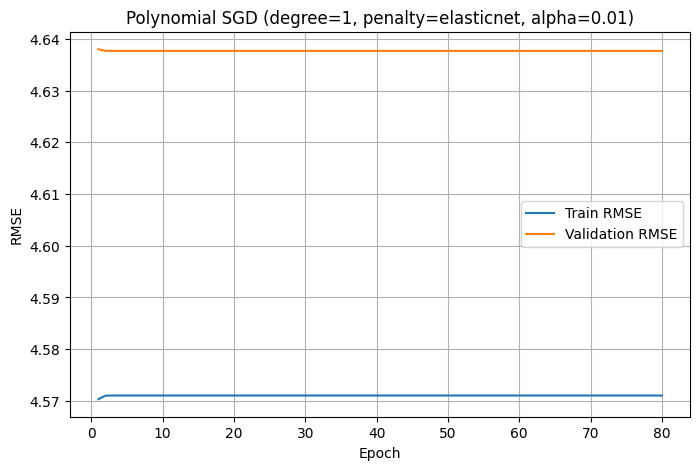


Final polynomial model trained on full training data.


In [8]:

# Part E: Polynomial Regression using SGD + 4-fold CV


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor

SEED = 42
np.random.seed(SEED)

# Target
target_column = "productivity_score"

# Use numeric features only, remove ID
df_model = df.drop(columns=["student_id"]).select_dtypes(include=[np.number]).dropna()

X = df_model.drop(columns=[target_column]).values
y = df_model[target_column].values

kf = KFold(n_splits=4, shuffle=True, random_state=SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Hyperparameters to explore
degrees = [1,2]
alphas = [0.001,0.01]
penalties = ["l2","elasticnet"]
l1_ratios = [0.15]

results = []

for deg in degrees:
    for pen in penalties:
        for a in alphas:

            ratios = l1_ratios if pen == "elasticnet" else [None]

            for l1r in ratios:
                fold_rmses = []

                for train_i, val_i in kf.split(X):
                    X_train, X_val = X[train_i], X[val_i]
                    y_train, y_val = y[train_i], y[val_i]

                    sgd_kwargs = dict(
                        loss="squared_error",
                        penalty=pen,
                        alpha=a,
                        max_iter=3000,
                        tol=1e-4,
                        random_state=SEED
                    )

                    if pen == "elasticnet":
                        sgd_kwargs["l1_ratio"] = l1r

                    model = Pipeline([
                        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
                        ("scaler", StandardScaler()),
                        ("sgd", SGDRegressor(**sgd_kwargs))
                    ])

                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_val)

                    fold_rmses.append(rmse(y_val, y_pred))

                results.append({
                    "degree": deg,
                    "penalty": pen,
                    "alpha": a,
                    "l1_ratio": l1r,
                    "cv_rmse": float(np.mean(fold_rmses))
                })

results_df = pd.DataFrame(results).sort_values("cv_rmse")
print("Top 10 configs by CV RMSE:")
print(results_df.head(10))

best = results_df.iloc[0]
print("\nBEST CONFIG:")
print(best)

best_degree = int(best["degree"])
best_penalty = best["penalty"]
best_alpha = float(best["alpha"])
best_l1_ratio = best["l1_ratio"] if pd.notna(best["l1_ratio"]) else None

# =========================
# Epoch-by-epoch RMSE curves (use one fold)
# =========================

train_i, val_i = next(kf.split(X))
X_train, X_val = X[train_i], X[val_i]
y_train, y_val = y[train_i], y[val_i]

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
scaler = StandardScaler()

X_train_p = poly.fit_transform(X_train)
X_val_p = poly.transform(X_val)

X_train_s = scaler.fit_transform(X_train_p)
X_val_s = scaler.transform(X_val_p)

EPOCHS = 80
eta0 = 0.01

sgd = SGDRegressor(
    loss="squared_error",
    penalty=best_penalty,
    alpha=best_alpha,
    l1_ratio=best_l1_ratio if best_penalty == "elasticnet" else 0.15,
    learning_rate="constant",
    eta0=eta0,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=SEED
)

train_rmse_hist, val_rmse_hist = [], []

for epoch in range(EPOCHS):
    sgd.fit(X_train_s, y_train)

    train_rmse_hist.append(rmse(y_train, sgd.predict(X_train_s)))
    val_rmse_hist.append(rmse(y_val, sgd.predict(X_val_s)))

plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_rmse_hist, label="Train RMSE")
plt.plot(range(1, EPOCHS+1), val_rmse_hist, label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title(f"Polynomial SGD (degree={best_degree}, penalty={best_penalty}, alpha={best_alpha})")
plt.legend()
plt.grid(True)
plt.show()


# Train final model on full dataset


final_kwargs = dict(
    loss="squared_error",
    penalty=best_penalty,
    alpha=best_alpha,
    max_iter=5000,
    tol=1e-4,
    random_state=SEED
)

if best_penalty == "elasticnet":
    final_kwargs["l1_ratio"] = best_l1_ratio

final_model_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(**final_kwargs))
])

final_model_poly.fit(X, y)
print("\nFinal polynomial model trained on full training data.")


Part E

Polynomial regression was applied using SGD in order to capture possible non-linear relationships between the features and the target variable productivity_score. Polynomial features were generated and evaluated using degrees 1 and 2. Ridge (L2) and Elastic Net regularization were tested with different values of the penalty parameter α to control model complexity and reduce overfitting.

Four-fold cross-validation was used to evaluate model performance using RMSE. The results showed that polynomial regression produced similar or slightly improved performance compared to the linear model. Training and validation RMSE were plotted across epochs for the best configuration. Both curves decreased rapidly during the early epochs and then stabilized at similar values, indicating that the model converged properly and did not exhibit strong overfitting.

The best performing configuration was selected based on the lowest cross-validation RMSE and was then trained on the full training dataset. This trained polynomial regression model will be used in Part F to evaluate performance on unseen data.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Train/test split (treat test split like the "test set" for Q2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Train final best polynomial model on training split
final_model_poly.fit(X_train, y_train)

# Predict + RMSE on test split
y_pred = final_model_poly.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", test_rmse)

Test RMSE: 4.54604753414252


Part F

In Part F, the final polynomial regression model selected in Part E was evaluated on a test dataset. The dataset was split into training and test sets using an 80/20 split. The model was trained on the training portion of the data and then used to generate predictions for the test set.

Model performance was measured using Root Mean Squared Error (RMSE), which evaluates the average prediction error between the predicted productivity scores and the actual values. The resulting test RMSE was approximately 4.55, indicating that the model’s predictions differ from the true productivity scores by about 4.55 points on average.

This evaluation demonstrates that the trained regression model is able to generalize reasonably well to unseen data, while maintaining stable performance across the dataset.